<a href="https://colab.research.google.com/github/ALVNOO/olist-ecommerce-dashboard/blob/main/Project_Analysis_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
path = '/content/drive/MyDrive/archive/'

customers = pd.read_csv(path + 'olist_customers_dataset.csv')
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

print("Semua dataset berhasil di-load!")

Semua dataset berhasil di-load!


Cek Ukuran Dataset

In [ ]:
datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

customers: 99,441 rows × 5 columns
orders: 99,441 rows × 8 columns
order_items: 112,650 rows × 7 columns
payments: 103,886 rows × 5 columns
reviews: 99,224 rows × 7 columns
products: 32,951 rows × 9 columns
sellers: 3,095 rows × 4 columns
category_translation: 71 rows × 2 columns


Cek Missing Values

In [ ]:
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

customers: 0 missing values
orders: 4908 missing values
order_items: 0 missing values
payments: 0 missing values
reviews: 145903 missing values
products: 2448 missing values
sellers: 0 missing values
category_translation: 0 missing values


In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Missing Values Per Kolom

In [ ]:
print("=== ORDERS ===")
print(orders.isnull().sum())

print("\n=== PRODUCTS ===")
print(products.isnull().sum())

print("\n=== REVIEWS ===")
print(reviews.isnull().sum())

=== ORDERS ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== PRODUCTS ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== REVIEWS ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Cek Tipe Data

In [ ]:
print(orders.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


Konversi Tanggal

In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Tipe data setelah konversi:")
print(orders.dtypes)

Tipe data setelah konversi:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


Handle missing values products

In [ ]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products[['product_weight_g','product_length_cm',
          'product_height_cm','product_width_cm']] = products[
    ['product_weight_g','product_length_cm',
     'product_height_cm','product_width_cm']].fillna(products[
    ['product_weight_g','product_length_cm',
     'product_height_cm','product_width_cm']].median())

print("Missing values products setelah cleaning:")
print(products.isnull().sum())

Missing values products setelah cleaning:
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64


Handle missing values reviews

In [ ]:
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No Title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No Comment')

print("Missing values reviews setelah cleaning:")
print(reviews.isnull().sum())

Missing values reviews setelah cleaning:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


Merge dataset

In [ ]:
# Merge orders + customers
df = orders.merge(customers, on='customer_id', how='left')

# Merge + order_items
df = df.merge(order_items, on='order_id', how='left')

# Merge + payments
df = df.merge(payments, on='order_id', how='left')

# Merge + products
df = df.merge(products, on='product_id', how='left')

# Merge + category translation
df = df.merge(category_translation, on='product_category_name', how='left')

# Merge + sellers
df = df.merge(sellers, on='seller_id', how='left')

print(f"Dataset master: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset master: 118,434 rows × 34 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


Tambah kolom-kolom baru yang berguna

In [ ]:
# Ekstrak tahun dan bulan dari tanggal pembelian
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['month_name'] = df['order_purchase_timestamp'].dt.strftime('%b')
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Hitung delivery time (hari)
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

# Hitung apakah pengiriman tepat waktu
df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

print("Kolom baru berhasil ditambahkan!")
print(df[['year_month', 'delivery_days', 'is_late']].head())

Kolom baru berhasil ditambahkan!
  year_month  delivery_days  is_late
0    2017-10            8.0    False
1    2017-10            8.0    False
2    2017-10            8.0    False
3    2018-07           13.0    False
4    2018-08            9.0    False


 Overview statistik penjualan

In [ ]:
print("=== RINGKASAN BISNIS ===")
print(f"Total Orders: {df['order_id'].nunique():,}")
print(f"Total Revenue: R$ {df['price'].sum():,.2f}")
print(f"Total Customers: {df['customer_unique_id'].nunique():,}")
print(f"Total Sellers: {df['seller_id'].nunique():,}")
print(f"Total Produk Terjual: {df['product_id'].nunique():,}")
print(f"Average Order Value: R$ {df.groupby('order_id')['price'].sum().mean():,.2f}")
print(f"Periode Data: {df['order_purchase_timestamp'].min().date()} s/d {df['order_purchase_timestamp'].max().date()}")

=== RINGKASAN BISNIS ===
Total Orders: 99,441
Total Revenue: R$ 14,209,250.31
Total Customers: 96,096
Total Sellers: 3,095
Total Produk Terjual: 32,951
Average Order Value: R$ 142.89
Periode Data: 2016-09-04 s/d 2018-10-17


 Distribusi order status

In [ ]:
print("=== STATUS ORDER ===")
print(df['order_status'].value_counts())

=== STATUS ORDER ===
order_status
delivered      115038
shipped          1245
canceled          745
unavailable       650
processing        375
invoiced          373
created             5
approved            3
Name: count, dtype: int64


Revenue per tahun

In [ ]:
revenue_yearly = df.groupby('year')['price'].sum().reset_index()
print("=== REVENUE PER TAHUN ===")
print(revenue_yearly)

=== REVENUE PER TAHUN ===
   year       price
0  2016    51220.49
1  2017  6483893.86
2  2018  7674135.96


Trend revenue bulanan

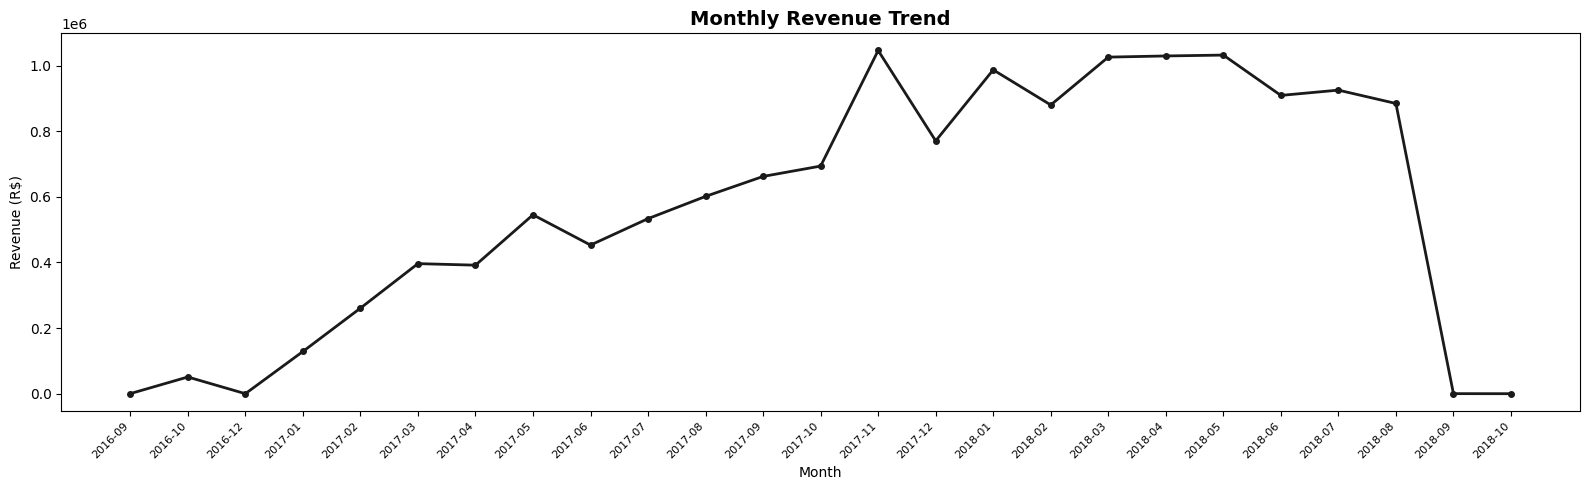

   year_month       price
0     2016-09      267.36
1     2016-10    50942.23
2     2016-12       10.90
3     2017-01   128637.99
4     2017-02   260753.86
5     2017-03   396451.04
6     2017-04   391784.42
7     2017-05   545340.65
8     2017-06   453031.41
9     2017-07   533616.84
10    2017-08   601409.67
11    2017-09   662276.39
12    2017-10   693807.60
13    2017-11  1046127.84
14    2017-12   770656.15
15    2018-01   987151.41
16    2018-02   880099.79
17    2018-03  1025936.06
18    2018-04  1029472.30
19    2018-05  1032150.44
20    2018-06   909221.10
21    2018-07   925302.46
22    2018-08   884657.40
23    2018-09      145.00
24    2018-10        0.00


In [ ]:
revenue_monthly = df.groupby('year_month')['price'].sum().reset_index()
revenue_monthly = revenue_monthly.sort_values('year_month')

plt.figure(figsize=(16,5))
plt.plot(revenue_monthly['year_month'], revenue_monthly['price'],
         marker='o', color='#1a1a1a', linewidth=2, markersize=4)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150)
plt.show()
print(revenue_monthly)

Top 10 kategori produk berdasarkan revenue

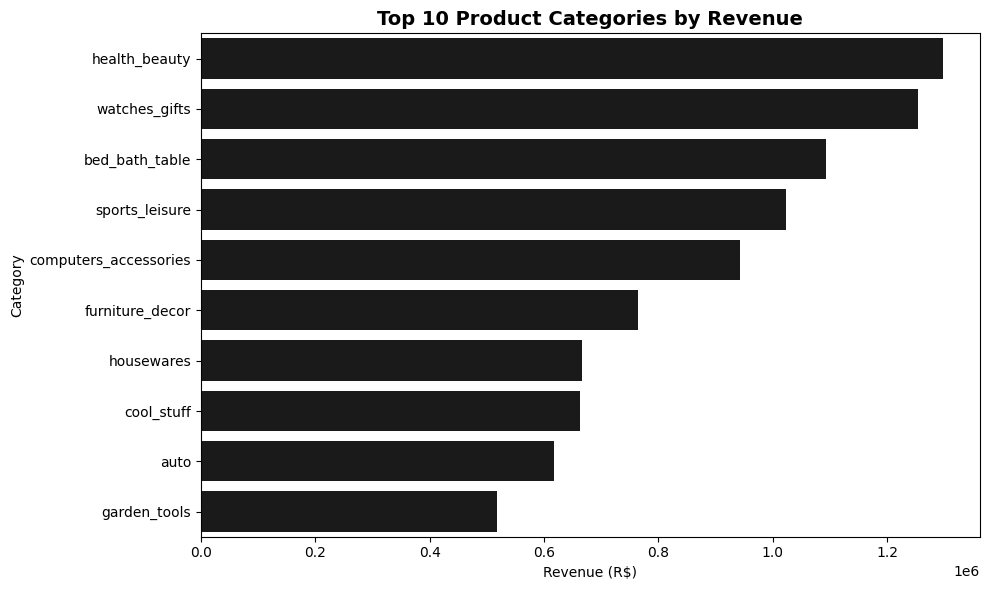

  product_category_name_english       price
0                 health_beauty  1297490.77
1                 watches_gifts  1253143.30
2                bed_bath_table  1092551.02
3                sports_leisure  1023996.34
4         computers_accessories   942277.57
5               furniture_decor   765093.89
6                    housewares   666587.00
7                    cool_stuff   662309.49
8                          auto   616752.51
9                  garden_tools   518217.54


In [ ]:
top_categories = df.groupby('product_category_name_english')['price'].sum()\
                   .sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_categories, x='price', y='product_category_name_english',
            color='#1a1a1a')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()
print(top_categories)

Distribusi review score

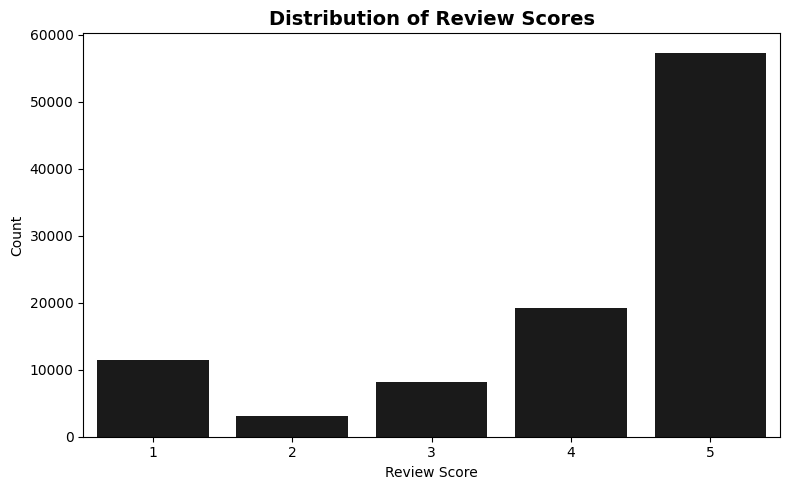

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [ ]:
review_dist = reviews['review_score'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=review_dist.index, y=review_dist.values, color='#1a1a1a')
plt.title('Distribution of Review Scores', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('review_dist.png', dpi=150)
plt.show()
print(review_dist)

Analisis keterlambatan pengiriman

In [ ]:
# Filter hanya order yang sudah delivered
delivered = df[df['order_status'] == 'delivered'].copy()
delivered = delivered.dropna(subset=['order_delivered_customer_date'])

late_count = delivered['is_late'].value_counts()
late_pct = (late_count[True] / len(delivered) * 100).round(2)

print(f"Total delivered orders: {len(delivered):,}")
print(f"Tepat waktu: {late_count[False]:,} ({100-late_pct}%)")
print(f"Terlambat: {late_count[True]:,} ({late_pct}%)")

# Rata-rata delivery days
print(f"\nRata-rata delivery time: {delivered['delivery_days'].mean():.1f} hari")
print(f"Delivery time tercepat: {delivered['delivery_days'].min()} hari")
print(f"Delivery time terlama: {delivered['delivery_days'].max()} hari")

Total delivered orders: 115,030
Tepat waktu: 106,004 (92.15%)
Terlambat: 9,026 (7.85%)

Rata-rata delivery time: 12.0 hari
Delivery time tercepat: 0.0 hari
Delivery time terlama: 209.0 hari


Hubungan keterlambatan vs review score

In [ ]:
delivered_reviews = delivered.merge(
    reviews[['order_id','review_score']],
    on='order_id', how='left'
)

avg_score = delivered_reviews.groupby('is_late')['review_score'].mean().round(2)
print("Rata-rata review score:")
print(f"Tepat waktu: {avg_score[False]}")
print(f"Terlambat: {avg_score[True]}")

Rata-rata review score:
Tepat waktu: 4.21
Terlambat: 2.55


Export dataset master ke CSV

In [ ]:
df_export = df[[
    'order_id', 'customer_unique_id', 'order_status',
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'year', 'month',
    'month_name', 'year_month', 'delivery_days', 'is_late',
    'price', 'freight_value', 'payment_type', 'payment_value',
    'product_id', 'product_category_name_english',
    'seller_id', 'customer_city', 'customer_state',
    'seller_city', 'seller_state'
]].copy()

export_path = '/content/drive/MyDrive/archive/'
df_export.to_csv(export_path + 'olist_master_clean.csv', index=False)

print(f"Export berhasil!")
print(f"Shape: {df_export.shape[0]:,} rows × {df_export.shape[1]} columns")
print(f"\nKolom yang diekspor:")
print(df_export.columns.tolist())

Export berhasil!
Shape: 118,434 rows × 23 columns

Kolom yang diekspor:
['order_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'month_name', 'year_month', 'delivery_days', 'is_late', 'price', 'freight_value', 'payment_type', 'payment_value', 'product_id', 'product_category_name_english', 'seller_id', 'customer_city', 'customer_state', 'seller_city', 'seller_state']


Ringkasan insight

In [ ]:
print("=" * 50)
print("RINGKASAN INSIGHT - OLIST E-COMMERCE")
print("=" * 50)
print(f"\n Total Orders      : {df['order_id'].nunique():,}")
print(f" Total Revenue     : R$ {df['price'].sum():,.0f}")
print(f" Total Customers   : {df['customer_unique_id'].nunique():,}")
print(f" Total Sellers     : {df['seller_id'].nunique():,}")
print(f" Avg Review Score  : {reviews['review_score'].mean():.2f} / 5.00")
print(f" On-time Delivery  : 92.15%")
print(f" Avg Delivery Time : 12 hari")
print(f" Top Category      : Health & Beauty")
print(f" Peak Revenue      : November 2017")
print(f"\n KEY INSIGHT:")
print(f"   Keterlambatan pengiriman menurunkan")
print(f"   review score dari 4.21 → 2.55 ")

RINGKASAN INSIGHT - OLIST E-COMMERCE

 Total Orders      : 99,441
 Total Revenue     : R$ 14,209,250
 Total Customers   : 96,096
 Total Sellers     : 3,095
 Avg Review Score  : 4.09 / 5.00
 On-time Delivery  : 92.15%
 Avg Delivery Time : 12 hari
 Top Category      : Health & Beauty
 Peak Revenue      : November 2017

 KEY INSIGHT:
   Keterlambatan pengiriman menurunkan
   review score dari 4.21 → 2.55 


In [ ]:
# Tambah review score ke dataset master
df_export2 = df_export.merge(
    reviews[['order_id','review_score']],
    on='order_id', how='left'
)

df_export2.to_csv(export_path + 'olist_master_clean.csv', index=False)
print(f"Berhasil! Shape: {df_export2.shape}")

Berhasil! Shape: (119143, 24)
